# BMW Global Automotive Sales - Classification Study

In this project, we analyze a dataset containing BMW Group global sales data from 2018 to 2025. The dataset includes information about sales volume, pricing, regional distribution, electric vehicle adoption, and macroeconomic indicators such as GDP growth and fuel prices.
We aim to predict continuous sales values based on features as model year, region, segment and other automotive values. The main path that is to follow will include:  <br>
-> EDA with visualizations <br>
-> building and comparing, tuning **classical ML models** as Linear Regression, Decision Trees, XGBoost, Random Forest <br>
-> building and comparing **Neural Network** architectures <br>
-> applying hyperparameter tuning, cross-validation and regularization
-> drawing conclusions

Dataset can be found here: [bmw](https://www.kaggle.com/datasets/dmahajanbe23/bmw-global-automotive-sales)

# 📦Section 1 : Setup
Installing and importing all required libraries:
- pandas, numpy for data
- matplotlib, seaborn, plotly for visualizations
- scikit-learn for classical ML models and preprocessing
- tensorflow / keras for Neural Networks

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import subprocess

# Check if required packages are installed, install them if missing
def install_package(package):
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install_package("pytorch-tabnet")
install_package("shap")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from pytorch_tabnet.tab_model import TabNetClassifier
import shap

Installing pytorch-tabnet...


# 📦 Section 2 : Data Loading
We will load our data using kaggle API.  <br>
#❗❗❗ This is an optional step
You can also just download dataset from link in the main description (Above Part 1).


In [51]:
!pip install kaggle -q
# Upload kaggle.json first and then
!kaggle datasets download -d dmahajanbe23/bmw-global-automotive-sales
!unzip bmw-global-automotive-sales.zip

Dataset URL: https://www.kaggle.com/datasets/dmahajanbe23/bmw-global-automotive-sales
License(s): CC0-1.0
bmw-global-automotive-sales.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  bmw-global-automotive-sales.zip
replace bmw_global_sales_2018_2025.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: bmw_global_sales_2018_2025.csv  


In [52]:
# Loading data into DataFrame

def data_loader(path: str) -> pd.DataFrame:

  try:
    df = pd.read_csv(path)
    print("Data loaded.")
  except FileNotFoundError:
    print("File not found.")
    return
  return df

file_path = "/content/bmw_global_sales_2018_2025.csv"

df = data_loader(file_path)


Data loaded.


# 📦Section 3 - EDA
Before building the model we must understand the structure of our data. In this section I will be dealing with duplicates, missing values, data types, correlations and grain.

In [53]:
# Displaying 5 top rows
df.head(5)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


In [54]:
print(f"Data shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("-------")
print(f"Column dtypes: \n{df.dtypes}")
print("-------")
print(f"Missing values: \n{df.isna().sum()}")
print("-------")
print(f"Duplicates: \n{df.duplicated().sum()}")

Data shape: 3072 rows x 11 columns
-------
Column dtypes: 
Year                  int64
Month                 int64
Region               object
Model                object
Units_Sold            int64
Avg_Price_EUR         int64
Revenue_EUR           int64
BEV_Share           float64
Premium_Share       float64
GDP_Growth          float64
Fuel_Price_Index    float64
dtype: object
-------
Missing values: 
Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64
-------
Duplicates: 
0


As we can see, our dataset has no missing values or duplicates. Now, we can check statistical summary:

In [55]:
df.describe().style.background_gradient(cmap='Purples').format('{:.2f}')

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.00,3072.00,3072.00,3072.00,3072.00,3072.00,3072.00,3072.00,3072.00
mean,2021.50,6.50,7980.29,63854.56,511399511.11,0.11,14.66,3.06,1.18
std,2.29,3.45,3174.92,14655.89,243118525.98,0.06,5.33,1.02,0.12
min,2018.00,1.00,2379.00,40011.00,104531427.00,-0.01,5.09,0.10,0.92
25%,2019.75,3.75,5225.50,54500.25,312550352.25,0.06,12.28,2.37,1.08
50%,2021.50,6.50,7985.50,63493.00,480868969.00,0.11,16.26,3.06,1.18
75%,2023.25,9.25,10528.25,71489.50,670914128.50,0.16,18.93,3.85,1.27
max,2025.00,12.00,15914.00,93994.00,1433481712.00,0.22,20.97,5.82,1.41


The dataset shows significant variability in the target variable (Units_Sold). This indicates that sales are influenced by multiple factors and are not constant across observations.
Average vehicle prices remain relatively stable, while revenue is strongly dependent on both price and units sold. Therefore, the `Revenue_EUR` feature may introduce data leakage and will be excluded from modeling.


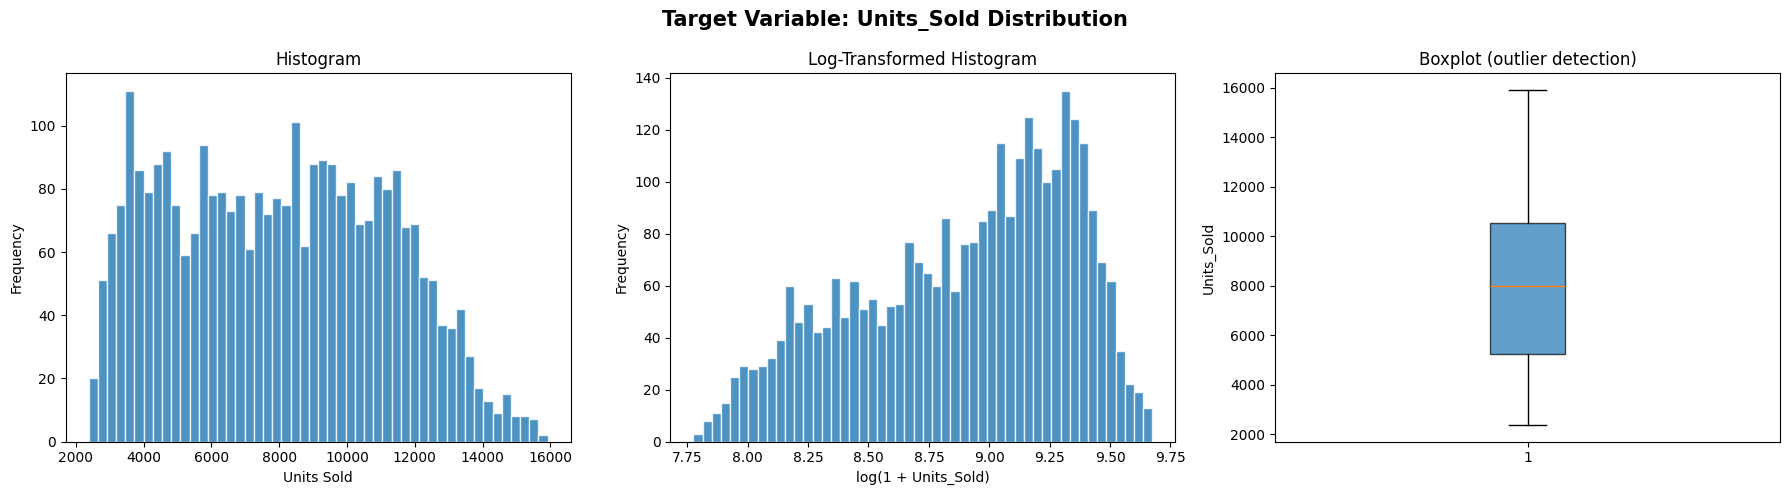

In [56]:
# Target Variable Distribution

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Target Variable: Units_Sold Distribution', fontsize=15, fontweight='bold')

# Histogram
axes[0].hist(df['Units_Sold'], bins=50, edgecolor='white', alpha=0.8)
axes[0].set_title('Histogram')
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('Frequency')

# Log-transformed
log_sales = np.log1p(df['Units_Sold'])
axes[1].hist(log_sales, bins=50, edgecolor='white', alpha=0.8)
axes[1].set_title('Log-Transformed Histogram')
axes[1].set_xlabel('log(1 + Units_Sold)')
axes[1].set_ylabel('Frequency')

# Box plot
axes[2].boxplot(df['Units_Sold'], patch_artist=True,
                boxprops=dict( alpha=0.7))
axes[2].set_title('Boxplot (outlier detection)')
axes[2].set_ylabel('Units_Sold')

plt.tight_layout()
plt.show()


The distribution of the target variable is slightly right-skewed, indicating that higher sales values occur less frequently but are still significant. Applying a logarithmic transformation reduces skewness. As we can see - there are no outliers.

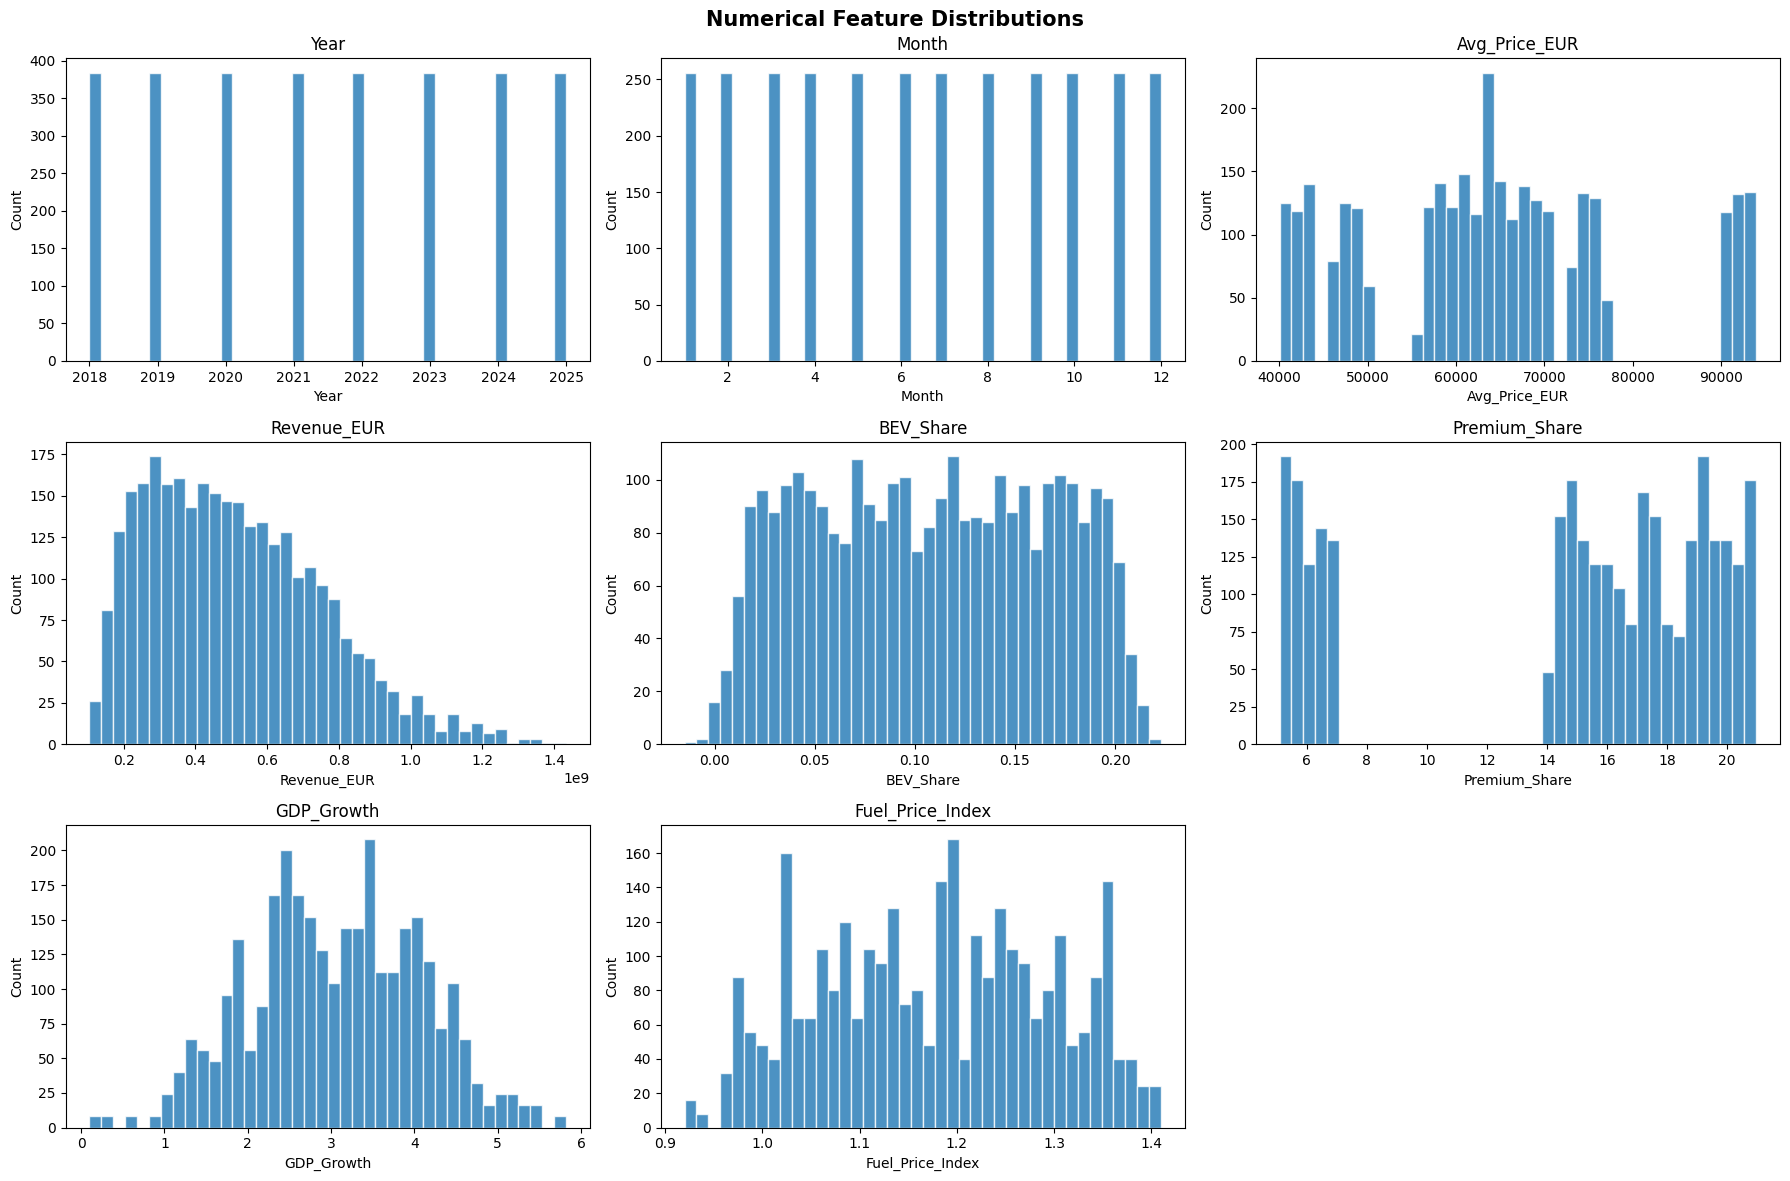

In [57]:
# We have no Categorial values in our dataset, so let's check Numerical Distributions
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'Units_Sold']

n_cols_plot = 3
n_rows_plot = (len(num_cols) + n_cols_plot - 1) // n_cols_plot
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 4 * n_rows_plot))
fig.suptitle('Numerical Feature Distributions', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40,
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- The dataset is evenly distributed across years and months, which ensures that the model will not be biased toward specific time periods.
- Vehicle prices show substantial variability, which may significantly influence sales volume and should be an important predictor in the model.
- As we recall, Revenue = Units_Sold × Price. The Revenue_EUR variable will be excluded from modeling due to potential data leakage, as it is directly dependent on the target variable.
- The share of electric vehicles shows moderate variation and may reflect evolving market trends influencing sales.
- Premium share varies significantly and may be a strong indicator of brand positioning.
- GDP growth shows relatively low variance, suggesting a more subtle influence on vehicle sales.

In [58]:
df = df.drop(columns=['Revenue_EUR'])

In [59]:
if 'Revenue_EUR' in num_cols:
    num_cols.remove('Revenue_EUR')

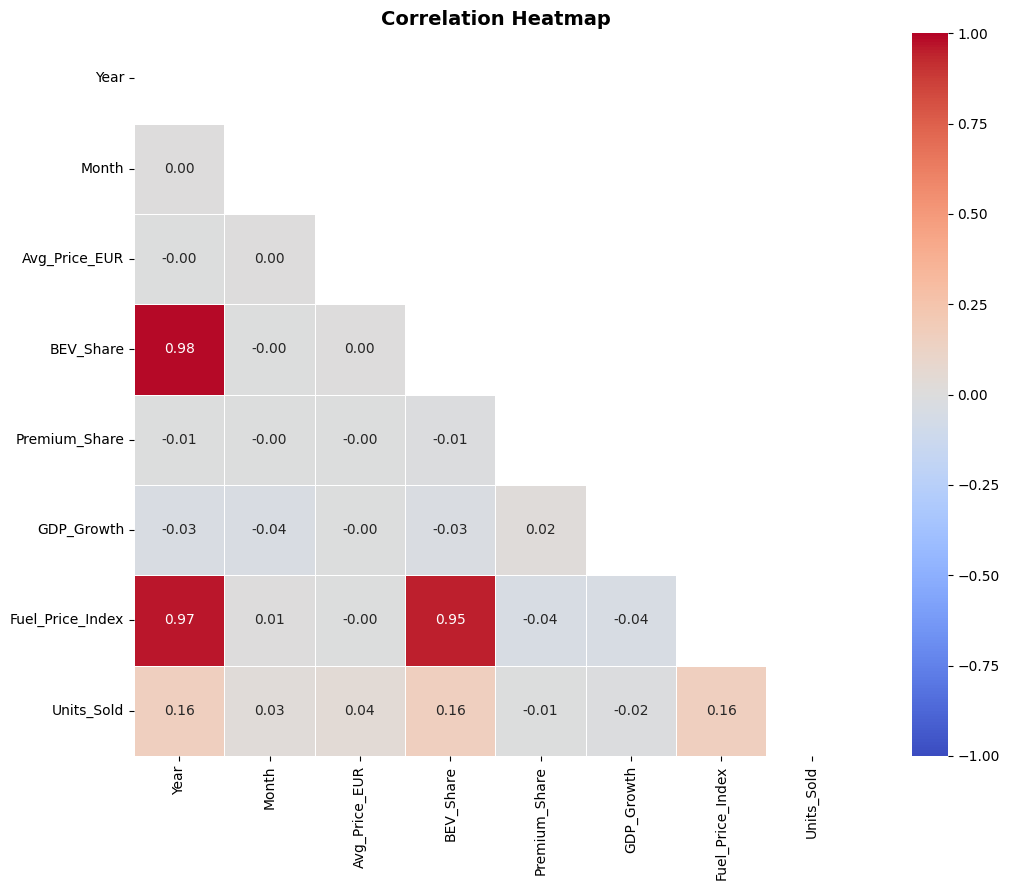

Year                0.163834
BEV_Share           0.159246
Fuel_Price_Index    0.158108
Avg_Price_EUR       0.039163
Month               0.030586
GDP_Growth          0.015432
Premium_Share       0.005594


In [60]:
# Correlation Heatmap
corr_matrix = df[num_cols + ['Units_Sold']].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

target_corr = corr_matrix['Units_Sold'].drop('Units_Sold').abs().sort_values(ascending=False)
print(target_corr.to_string())

The correlation analysis shows that no single feature has a strong linear relationship with the target variable. This suggests that the problem is likely driven by complex, non-linear interactions between variables, making tree-based models such as Random Forest and XGBoost more suitable.